# Clean incident-retrieval model selection

This notebook compares BM25, MiniLM, and Mixedbread using the clean agent's frozen retrieval contract. It does not need Kubernetes, Redis, n8n, the dashboard, or an API key.

## What is being tested

`evidence -> stable EvidenceTemplate -> fingerprint exact check -> BM25 candidates -> optional local reranker`

Each stored example contains evidence plus approved hints. Exact fingerprints bypass reranking; all other cases produce one of `exact / nearest / none / degraded`. MiniLM and Mixedbread receive the same BM25 candidate set.

The LLM judge is intentionally excluded: it is outside the local retrieval comparison and adds provider cost, latency, and non-determinism.


## 1. Get the clean code and lightweight dependency

Restart the Colab runtime, then use **Runtime → Run all**. Model-specific dependencies are installed in a later section.


In [1]:
!git clone https://github.com/Ama2352/vroom-services.git
%cd /content/vroom-services/incident-diagnosis/evaluation
!pip -q install rank-bm25

Cloning into 'vroom-services'...
remote: Enumerating objects: 4233, done.
remote: Counting objects: 100% (589/589), done.
remote: Compressing objects: 100% (360/360), done.
remote: Total 4233 (delta 298), reused 474 (delta 214), pack-reused 3644 (from 1)
Receiving objects: 100% (4233/4233), 4.55 MiB | 13.15 MiB/s, done.
Resolving deltas: 100% (2532/2532), done.
/content/vroom-services/incident-diagnosis/evaluation


## 2. Load the frozen cases

`historical_context_enriched_snapshot.json` keeps the clean `families`, `examples`, and `hints` schema while adding archived runbook context as approved historical hints. No production data is read or changed.


In [2]:
from pathlib import Path
import sys

EVALUATION_ROOT = Path.cwd()
AGENT_ROOT = EVALUATION_ROOT.parent / 'agent'
sys.path[:0] = [str(AGENT_ROOT), str(EVALUATION_ROOT)]

from benchmark import evidence_category_coverage, field_coverage, load_cases, load_snapshot, pipeline_trace, validate_semantic_cases

cases = load_cases(EVALUATION_ROOT / 'fixtures' / 'retrieval_cases.json')
semantic_cases = load_cases(EVALUATION_ROOT / 'fixtures' / 'semantic_disambiguation_cases.json')
snapshot = load_snapshot(EVALUATION_ROOT / 'fixtures' / 'historical_context_enriched_snapshot.json')
validate_semantic_cases(semantic_cases, snapshot)
calibration_cases = tuple(case for case in cases if case.split == 'calibration')
held_out_cases = tuple(case for case in cases if case.split == 'held_out')
held_out_positive_cases = tuple(case for case in held_out_cases if case.expected_mode != 'none')
held_out_no_match_cases = tuple(case for case in held_out_cases if case.expected_mode == 'none')
assert len(cases) == 40
assert len(calibration_cases) == len(held_out_cases) == 20
assert len(held_out_positive_cases) == len(held_out_no_match_cases) == 10
print(f'{len(cases)} frozen cases; {len(snapshot["examples"])} approved examples')
print(f'{len(held_out_positive_cases)} held-out positive cases; {len(held_out_no_match_cases)} held-out no-match cases')
for benchmark_name, benchmark_cases in [('Historical', cases), ('Semantic', semantic_cases)]:
    coverage = field_coverage(benchmark_cases)
    print(f'{benchmark_name} field coverage:', {field: f'{value:.0%}' for field, value in coverage.items()})
print('Evidence categories:', evidence_category_coverage((*cases, *semantic_cases)))

40 frozen cases; 26 approved examples
10 held-out positive cases; 10 held-out no-match cases
Historical field coverage: {'service': '0%', 'triggering_metric': '100%', 'log_error': '78%', 'trace_error_service': '0%', 'trace_error_operation': '0%', 'trace_error_message': '0%', 'configuration_diff': '0%'}
Semantic field coverage: {'service': '69%', 'triggering_metric': '100%', 'log_error': '88%', 'trace_error_service': '12%', 'trace_error_operation': '12%', 'trace_error_message': '12%', 'configuration_diff': '12%'}
Evidence categories: {'kubernetes_heavy': 18, 'metrics_plus_logs': 45, 'logs_plus_traces': 2, 'configuration_related': 2, 'sparse_no_match': 12, 'conflicting_evidence': 9}


## 3. Download pinned local rerankers

The download is revision-pinned and the ONNX artifact is checksum-verified. These models stay local to the Colab runtime.


In [3]:
!pip -q install transformers onnxruntime huggingface_hub numpy matplotlib psutil

from huggingface_hub import snapshot_download
from reranker import MiniLMReranker, ModelSpec, OnnxCrossEncoder, verify_sha256
from benchmark import IdentityReranker, calibrate_score_floor, evaluate_selection_gate, load_model_specs, retrieve_case, run_raw_ranking, run_system

model_specs = load_model_specs(EVALUATION_ROOT / 'model_specs.json')

def download_model(name):
    spec = model_specs[name]
    model_dir = Path(snapshot_download(
        repo_id=spec['repo_id'], revision=spec['revision'],
        allow_patterns=['*.json', '*.txt', '*.model', 'onnx/*.onnx'],
    ))
    verify_sha256(model_dir / spec['onnx_file'], spec['sha256'])
    return model_dir, spec

def build_reranker(model_dir, spec):
    backend = OnnxCrossEncoder(model_dir, ModelSpec(**spec))
    return MiniLMReranker(backend)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 42.3 MB/s eta 0:00:00


## 4. Run the same pipeline for every system

BM25 selects candidates first. The two neural models can only reorder that same small candidate set. Exact fingerprint matches bypass every reranker.


In [4]:
import json
import numpy as np
import subprocess

def measure_local_system(name):
    model_dir, _spec = download_model(name)
    # Probe in a new process so another loaded model cannot inflate RSS.
    completed = subprocess.run(
        [sys.executable, 'resource_probe.py', '--name', name, '--model-dir', str(model_dir)],
        check=True, capture_output=True, text=True,
    )
    return json.loads(completed.stdout)

bm25 = IdentityReranker()
bm25_floor = calibrate_score_floor(cases, snapshot, bm25, name='bm25')
if not np.isfinite(bm25_floor):
    raise RuntimeError('BM25 could not find a safe calibration threshold.')
results = {'bm25': run_system(held_out_cases, snapshot, bm25, name='bm25', score_floor=bm25_floor)}
operations = {'bm25': {'artifact_mb': 0.0, 'cold_load_ms': 0.0, 'p50_ms': 0.0, 'p95_ms': 0.0, 'peak_rss_mb': 0.0}}
score_floors = {'bm25': bm25_floor}
rerankers = {'bm25': bm25}
unavailable = {}

for name in ('minilm', 'mixedbread_xsmall'):
    try:
        operations[name] = measure_local_system(name)
        reranker = build_reranker(*download_model(name))
        rerankers[name] = reranker
        floor = calibrate_score_floor(cases, snapshot, reranker, name=name)
        if not np.isfinite(floor):
            raise RuntimeError('could not find a safe calibration threshold')
        score_floors[name] = floor
        results[name] = run_system(held_out_cases, snapshot, reranker, name=name, score_floor=floor)
    except Exception as exc:
        unavailable[name] = f'{type(exc).__name__}: {exc}'

assert all(result.advisory_positive_count == len(held_out_positive_cases) for result in results.values())
semantic_results = {
    name: run_system(semantic_cases, snapshot, rerankers[name], name=name, score_floor=score_floors[name])
    for name in results
}
raw_historical_results = {name: run_raw_ranking(held_out_positive_cases, snapshot, rerankers[name], name=name) for name in results}
raw_semantic_results = {name: run_raw_ranking(semantic_cases, snapshot, rerankers[name], name=name) for name in results}
semantic_provenance_results = {
    provenance: {name: run_system(tuple(case for case in semantic_cases if case.provenance == provenance), snapshot, rerankers[name], name=name, score_floor=score_floors[name]) for name in results}
    for provenance in ('archive_derived', 'synthetic_stress')
}
print('Calibration score floors:', score_floors)
print('Unavailable systems:', unavailable or 'none')

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Calibration score floors: {'bm25': 9.139915471922995, 'minilm': 7.159183502197266, 'mixedbread_xsmall': 0.8416229486465454}
Unavailable systems: none


## 5. Quality metrics

Both benchmarks report exact correctness, Top-1, MRR, Recall@3, false positives, and abstentions. The semantic slice contains keyword-sharing competitors; Top-1 and MRR are its primary measures. A confusion matrix is intentionally omitted because this is a retrieval-ranking comparison with multiple valid candidates and abstentions, not a single-label classifier.


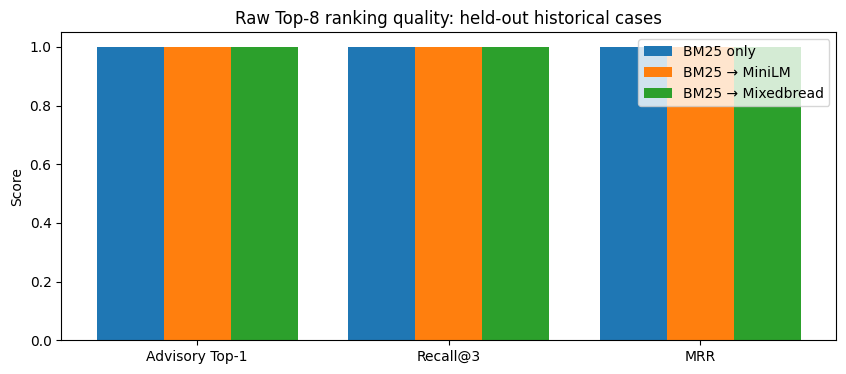

Exact fingerprint cases are calibration-only; they are not plotted as held-out ranking quality.


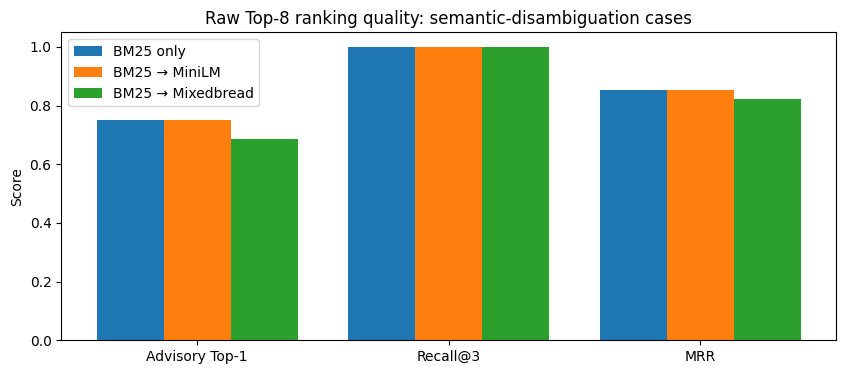


Historical complete pipeline
BM25 only            exact=0/0 top1=1.00 mrr=1.00 recall@3=1.00 false_positives=0 abstentions=10
BM25 → MiniLM        exact=0/0 top1=0.60 mrr=0.60 recall@3=0.60 false_positives=0 abstentions=10
BM25 → Mixedbread    exact=0/0 top1=0.30 mrr=0.30 recall@3=0.30 false_positives=0 abstentions=10

Semantic complete pipeline
BM25 only            exact=0/0 top1=0.69 mrr=0.75 recall@3=0.81 false_positives=0 abstentions=0
BM25 → MiniLM        exact=0/0 top1=0.12 mrr=0.12 recall@3=0.12 false_positives=0 abstentions=0
BM25 → Mixedbread    exact=0/0 top1=0.19 mrr=0.19 recall@3=0.19 false_positives=0 abstentions=0

Semantic provenance: archive_derived (not historical unless archive_derived)
BM25 only            top1=1.00 mrr=1.00 recall@3=1.00 false_positives=0 abstentions=0
BM25 → MiniLM        top1=0.25 mrr=0.25 recall@3=0.25 false_positives=0 abstentions=0
BM25 → Mixedbread    top1=0.25 mrr=0.25 recall@3=0.25 false_positives=0 abstentions=0

Semantic provenance: synth

In [5]:
import matplotlib.pyplot as plt

def ratio(numerator, denominator):
    return numerator / denominator if denominator else 0.0

names = list(results)
display_names = {
    'bm25': 'BM25 only',
    'minilm': 'BM25 → MiniLM',
    'mixedbread_xsmall': 'BM25 → Mixedbread',
}
quality = {
    name: [
        ratio(result.advisory_top1, result.advisory_positive_count),
        ratio(result.advisory_recall_at_3, result.advisory_positive_count),
        ratio(result.advisory_mrr_sum, result.advisory_positive_count),
    ]
    for name, result in raw_historical_results.items()
}

labels = ['Advisory Top-1', 'Recall@3', 'MRR']
x = np.arange(len(labels))
width = 0.8 / len(names)
fig, ax = plt.subplots(figsize=(10, 4))
for index, name in enumerate(names):
    ax.bar(x - 0.4 + width / 2 + index * width, quality[name], width, label=display_names[name])
ax.set_xticks(x, labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Raw Top-8 ranking quality: held-out historical cases')
ax.legend()
plt.show()
print('Exact fingerprint cases are calibration-only; they are not plotted as held-out ranking quality.')

semantic_quality = {
    name: [ratio(result.advisory_top1, result.advisory_positive_count), ratio(result.advisory_recall_at_3, result.advisory_positive_count), ratio(result.advisory_mrr_sum, result.advisory_positive_count)]
    for name, result in raw_semantic_results.items()
}
fig, ax = plt.subplots(figsize=(10, 4))
for index, name in enumerate(names):
    ax.bar(x - 0.4 + width / 2 + index * width, semantic_quality[name], width, label=display_names[name])
ax.set_xticks(x, labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Raw Top-8 ranking quality: semantic-disambiguation cases')
ax.legend()
plt.show()

for benchmark_name, benchmark_results in [('Historical complete pipeline', results), ('Semantic complete pipeline', semantic_results)]:
    print(f'\n{benchmark_name}')
    for name, result in benchmark_results.items():
        print(f'{display_names[name]:20} exact={result.exact_correct}/{result.exact_total} top1={ratio(result.advisory_top1, result.advisory_positive_count):.2f} mrr={ratio(result.advisory_mrr_sum, result.advisory_positive_count):.2f} recall@3={ratio(result.advisory_recall_at_3, result.advisory_positive_count):.2f} false_positives={result.false_positives} abstentions={result.correct_abstentions}')

for provenance, provenance_results in semantic_provenance_results.items():
    print(f'\nSemantic provenance: {provenance} (not historical unless archive_derived)')
    for name, result in provenance_results.items():
        print(f'{display_names[name]:20} top1={ratio(result.advisory_top1, result.advisory_positive_count):.2f} mrr={ratio(result.advisory_mrr_sum, result.advisory_positive_count):.2f} recall@3={ratio(result.advisory_recall_at_3, result.advisory_positive_count):.2f} false_positives={result.false_positives} abstentions={result.correct_abstentions}')

print('\nSemantic pipeline traces (BM25 → raw reranker → threshold → accepted):')
for case in semantic_cases:
    print(f'\n{case.case_id}: expected={case.expected_keys}; competitors={case.competing_keys}')
    for name in names:
        print(display_names[name], pipeline_trace(case, snapshot, rerankers[name], name=name, score_floor=score_floors[name]))

## 6. Safety gate and Operational metrics

A local reranker must have no forbidden result, false positive, exact failure, or degraded result. It must also match or exceed BM25 ranking quality, stay below 1,000 ms p95 latency, and use at most 500 MB peak RSS. Each RSS value is measured in a fresh process, matching the archived tournament method.


bm25               status=rejected deltas={'top1': 0.0, 'recall_at_3': 0.0, 'mrr': 0.0} reasons=('retrieval safety gate failed',)
minilm             status=rejected deltas={'top1': -0.4, 'recall_at_3': -0.4, 'mrr': -0.4} reasons=('operational latency or memory gate failed', 'material retrieval-quality regression', 'small regression has no compensating quality gain')
mixedbread_xsmall  status=rejected deltas={'top1': -0.7, 'recall_at_3': -0.7, 'mrr': -0.7} reasons=('operational latency or memory gate failed', 'material retrieval-quality regression', 'small regression has no compensating quality gain')


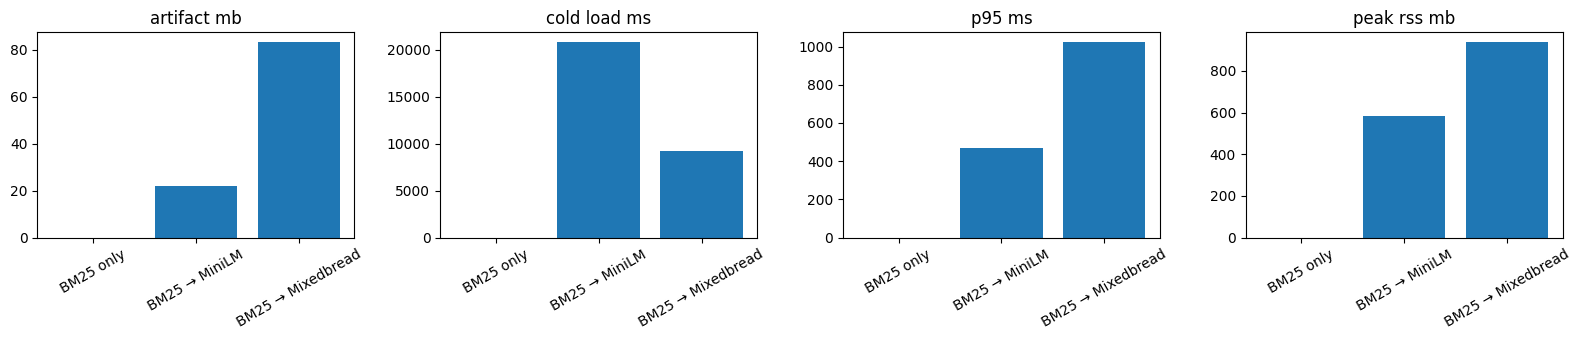

Decision: inconclusive — BM25 remains a comparison baseline; no local reranker passed every gate.


In [6]:
baseline = results['bm25']
eligibility = {}
gate_results = {}
for name, result in results.items():
    gate_results[name] = evaluate_selection_gate(result, baseline=baseline, p95_ms=operations[name]['p95_ms'], peak_rss_mb=operations[name]['peak_rss_mb'])
    eligibility[name] = name != 'bm25' and gate_results[name].status == 'selected'
    print(f'{name:18} status={gate_results[name].status} deltas={gate_results[name].quality_deltas} reasons={gate_results[name].reasons or ("no material regression",)}')

metrics = ['artifact_mb', 'cold_load_ms', 'p95_ms', 'peak_rss_mb']
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for axis, metric in zip(axes, metrics):
    axis.bar(range(len(names)), [operations[name][metric] for name in names])
    axis.set_title(metric.replace('_', ' '))
    axis.set_xticks(range(len(names)), [display_names[name] for name in names])
    axis.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

candidates = [name for name in names if name != 'bm25' and eligibility[name]]
if candidates:
    winner = min(candidates, key=lambda name: (operations[name]['p95_ms'], operations[name]['artifact_mb']))
    print(f'Decision: choose {display_names[winner]}; it passed the quality, safety, latency, and memory gates.')
else:
    print('Decision: inconclusive — BM25 remains a comparison baseline; no local reranker passed every gate.')